In [ ]:
from typing import Literal, Optional

import neo
import neo.io
from neo.core import SpikeTrain, AnalogSignal
import numpy as np
from numpy.typing import NDArray
import quantities as pq
from quantities import Quantity
from quantities.unitquantity import UnitQuantity
from matplotlib import pyplot as plt
import elephant.spike_train_correlation as corr
import elephant.spike_train_surrogates as surr
import elephant.statistics as stats
import elephant.conversion as conv
import matplotlib as mpl

%matplotlib inline

# Cross-Correlation Histograms of Neuronal Spike Trains and Surrogate Methods for Null-Hypothesis Testing

Spike trains provide a compact record of neuronal activity, but their temporal structure is difficult to interpret from raw event times alone. In this notebook, we examine how visualisation, cross-correlation analysis, and surrogate-based hypothesis testing can be used to evaluate temporal relationships between neurons. We first characterise single-neuron spike train structure, then estimate pairwise timing relationships using cross-correlation histograms. Finally, we compare observed correlations against surrogate null distributions to assess whether apparent temporal structure exceeds what would be expected from selected features of the individual spike trains.

## Setup

### Utility Functions

In [ ]:
class utils:

    @staticmethod
    def load_spike_trains(nix_path):
        """Load all trials for one neuron from the data directory."""
        with neo.io.NixIO(nix_path, "ro") as io:
            return [seg.spiketrains[0][:-1] for seg in io.read_block().segments]
    
    @staticmethod
    def get_spike_times(spike_trains: list[SpikeTrain]) -> list[Quantity]:
        return [st.times.rescale('ms') for st in spike_trains]
    
    @staticmethod
    def get_isis(spike_trains: list[SpikeTrain]) -> list[Quantity]:
        return [np.diff(st.times, prepend=np.nan) * st.units for st in spike_trains]

    def get_isi_histogram(spike_trains: list[SpikeTrain], bin_size: Quantity, density: bool = False) -> tuple[Quantity, Quantity]:
        bin_edges = utils._qrange(spike_trains[0].t_start, spike_trains[0].t_stop, bin_size, inclusive=True)
        all_isis = np.concatenate(utils.get_isis(spike_trains))
        counts, bin_edges = np.histogram(all_isis, bins=bin_edges)
        if not density:
            return counts * bin_size.units, bin_edges
        else:
            weights = (counts / np.mean(counts)) * pq.dimensionless
            return weights, bin_edges

    @staticmethod
    def get_spike_time_histogram(spike_trains: list[SpikeTrain], bin_size: Quantity, density: bool = False) -> tuple[Quantity, Quantity]:
        bin_edges = utils._qrange(spike_trains[0].t_start, spike_trains[0].t_stop, bin_size, inclusive=True)
        spike_times = utils.get_spike_times(spike_trains)
        counts = np.diff(np.searchsorted(np.sort(np.concatenate(spike_times)), bin_edges, side='left'))
        if not density:
            return counts * pq.dimensionless, bin_edges
        else:
            weight = counts / np.mean(counts)
            return weight * pq.dimensionless, bin_edges

    @staticmethod
    def get_isi_time_histogram(spike_trains: list[SpikeTrain], bin_size: Quantity, agg=np.nanmedian, density: bool = False) -> tuple[Quantity, Quantity]:
        bin_edges = utils._qrange(sts[0].t_start, sts[0].t_stop, bin_size, inclusive=True)
        times = utils.get_spike_times(spike_trains)
        isis = utils.get_isis(spike_trains)

        binned_averages = []
        for ii, td in zip(isis, times):
            bin_indices = np.searchsorted(td, bin_edges)
            binned_average = np.array([np.nanmedian(ii[l:r]) for l,r in zip(bin_indices[:-1], bin_indices[1:])])
            binned_averages.append(binned_average)

        avg_averages = np.nanmedian(binned_averages, axis=0)
        if not density:
            return avg_averages * bin_edges.units, bin_edges
        else:
            weight = avg_averages / np.mean(avg_averages)
            return weight * pq.dimensionless, bin_edges
    
    @staticmethod
    def _qrange(start: Quantity, stop: Quantity, bin_size: Quantity, inclusive=False) -> list[Quantity]:
        start = start.rescale(bin_size.units)
        stop = stop + bin_size if inclusive else stop
        stop = stop.rescale(bin_size.units)
        return np.arange(start.item(), stop.item(), bin_size.item()) * bin_size.units

    @staticmethod
    def eventplot_colored(positions: Quantity | list[Quantity], colors: Quantity | list[Quantity] = None, cmap='viridis', gamma: float = 1., vmin_perc: float = .025, vmax_perc = .975, ax=None):
    
        # Distribute colors as a power distribution, then get colors as RGBA values
        if colors is None:
            colors = positions
            
        if isinstance(colors, Quantity):
            cdata = colors
        elif isinstance(colors[0], Quantity):
            cdata = np.concatenate(colors)
        else:
            raise TypeError("colors should be a Quantity or Sequence of Quantities")
        
        norm = mpl.colors.PowerNorm(
            gamma = gamma, 
            vmin = np.nanpercentile(cdata, vmin_perc * 100) , 
            vmax = np.nanpercentile(cdata, vmax_perc * 100) ,
        )
        cmap = plt.get_cmap(cmap)
        mapper = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        if isinstance(colors, Quantity):
            rgba = mapper.to_rgba(colors)
        else:
            rgba = [mapper.to_rgba(val) for val in colors]
    
        # make event plot with the RGBA colors and a colorbar.
        ax = plt.gca() if ax is None else ax
        ax.eventplot(positions=positions, colors=rgba)
        plt.colorbar(mapper, cax=ax.inset_axes([1.04, 0.0, 0.05, 1.0]))

    @staticmethod
    def compute_cch_avg(spike_trains1: list[SpikeTrain], spike_trains2: list[SpikeTrain], bin_size: Quantity, maxlag: Quantity) -> AnalogSignal:
        num_lags = int((maxlag / bin_size).magnitude)
        cchs = []
        for st1, st2 in zip(spike_trains1, spike_trains2):
            b1 = conv.BinnedSpikeTrain(st1, bin_size)
            b2 = conv.BinnedSpikeTrain(st2, bin_size)
            cch, _ = corr.cross_correlation_histogram(b1, b2, window=[-num_lags, num_lags])
            cchs.append(cch)
        cch_avg = sum(cchs) / len(cchs)
        return cch_avg
    
    @staticmethod
    def plot_cch(cch, cch_mean_surr=None, cch_threshold=None, title="CCH"):
        fig, ax = plt.subplots(figsize=(7, 4))
        lags = cch.times.rescale("ms").magnitude
        ax.plot(lags, cch.magnitude, "k-", label="CCH")
        if cch_mean_surr is not None:
            ax.plot(lags, cch_mean_surr, "g-", label="mean surrogate CCH")
        if cch_threshold is not None:
            ax.plot(lags, cch_threshold, "r--", label="95th percentile")
        ax.set_xlabel("Lag (ms)")
        ax.set_ylabel("Count")
        ax.set_title(title)
        ax.legend()
        ax.grid(True)

    @staticmethod
    def find_peak_lag(cch_avg: AnalogSignal) -> Quantity:
        return cch_avg.times[np.argmax(cch_avg.magnitude)].rescale("ms")

    @staticmethod
    def compute_surrogate_cchs(surr1, surr2, n_surr, bin_size, maxlag):
        num_lags = int((maxlag / bin_size).magnitude)
        len_cch = 2 * num_lags + 1
        cchs_surr = np.zeros((n_surr, len_cch))
        for surr_id in range(n_surr):
            sts1 = [st[surr_id] for st in surr1]
            sts2 = [st[surr_id] for st in surr2]
            for st1, st2 in zip(sts1, sts2):
                b1 = conv.BinnedSpikeTrain(st1, bin_size)
                b2 = conv.BinnedSpikeTrain(st2, bin_size)
                cchs_surr[surr_id] += corr.cross_correlation_histogram(
                    b1, b2, window=(-num_lags, num_lags)
                )[0].reshape(len_cch)
            cchs_surr[surr_id] /= len(sts1)
        return cchs_surr
    
    

### Download Data

The data consists of simultaneously recorded spike trains from pairs of neurons in the motor cortex of a macaque monkey performing a delayed reaching task. Each dataset contains spike trains across multiple trials. The following pairs are available for analysis: [28, 29], [23, 24] (simulated data), [12, 13], [14, 15], [20, 21], [21, 22] (experimental data).

In [ ]:
import os
import owncloud
from tqdm import tqdm

oc = owncloud.Client.from_public_link('https://uni-bonn.sciebo.de/s/9ng75jH88MZ4MZW', folder_password='ibots')

os.makedirs('data', exist_ok=True)
for f in tqdm(oc.list('/'), desc='Downloading Files to data/'):
    if not os.path.exists(f'data{f.path}'):
        oc.get_file(f.path, f'data{f.path}')

## Visualizing Spike Train Histograms: Spike Times and Inter-Spike Intervals (ISIs)

A spike train is a sequence of events in time. Before we compare neurons, we need to understand what one neuron is doing. Raster plots show when spikes happen in single trials and across trials. Histograms help us see whether firing changes during the trial. Inter-spike intervals add another view by showing how closely spaced the spikes are. Together, these views help us decide whether a neuron has stable firing or time-dependent activity.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`utils.load_spike_trains("data/Data1.nix")`** | Load all trials for one neuron from the data file. |
| **Raster Plots** |  |
| **`utils.get_spike_times(spike_trains)`** | Get the spike times from each trial. |
| **`plt.eventplot(spike_times[index])`** | Make a raster plot for one trial. Replace `index` with the trial number you want. |
| **`plt.eventplot(spike_times)`** | Make a raster plot for all trials at once. |
| **`utils.get_isis(spike_trains)`** | Calculate inter-spike intervals, or ISIs, for each trial. |
| **`utils.eventplot_colored(spike_times, isis, gamma=..., vmin_perc=..., vmax_perc=...)`** | Make a raster plot where each spike is colored by its ISI value.  |
| **Time Histograms** |  |
| **`utils.get_spike_time_histogram(spike_trains, bin_size=... * pq.ms)`** | Count spikes in time bins of a chosen size. |
| **`plt.stairs(counts, time_bins)`** | Plot histogram data as a step plot. |
| **`utils.get_isi_time_histogram(spike_trains, bin_size=... * pq.ms)`** | Calculate how the average ISI changes over time.  |


### Exercises

**Example**: Load the spike trains from Data1's neuron, extract its spike times, and plot the first spike train (i.e. index `0`) as a raster plot.

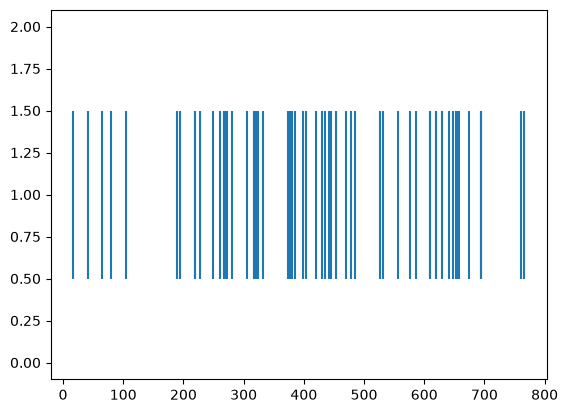

In [ ]:
spike_trains = utils.load_spike_trains("data/Data1.nix")
spike_times = utils.get_spike_times(spike_trains)
plt.eventplot(spike_times[0]);

**Exercise**: Load the spike trains from Data1's neuron, extract its spike times, and plot the third spike train (i.e. index `2`) as a raster plot.

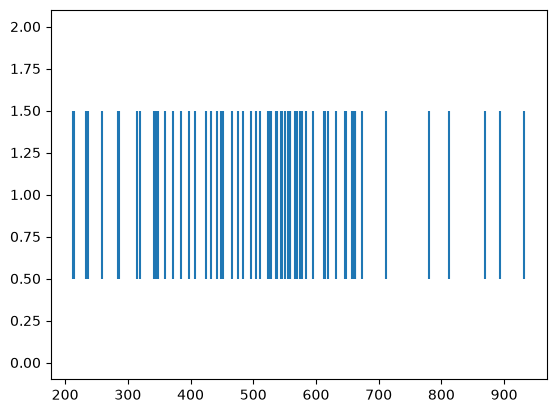

In [ ]:
spike_trains = utils.load_spike_trains("data/Data1.nix")
spike_times = utils.get_spike_times(spike_trains)
plt.eventplot(spike_times[2]);

**Exercise**: Make a raster plot from all of Data1's spike times. (*Hint*: no loops needed; `plt.eventplot()` can plot all of the spike trains at once!)  Does this neuron show **stationary** or **nonstationary** spiking behavior?

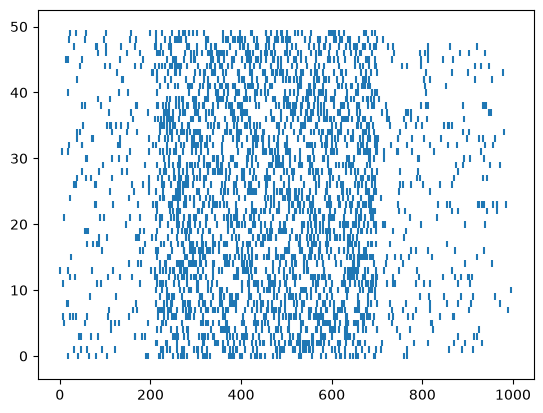

In [ ]:
spike_trains = utils.load_spike_trains("data/Data1.nix")
spike_times = utils.get_spike_times(spike_trains)
plt.eventplot(spike_times);

**Example**: Show that the number of spikes changes over time on average across trials by making a **time histogram**.
  - The histogram data can be calculated with `utils.get_spike_time_histogram()`. The `bin_size` parameter is a `Quantity` object; it needs both a value and a unit (e.g. `30 * pq.ms` to say 30msecs).
  - `plt.stairs()` is useful for plotting histogram data. 

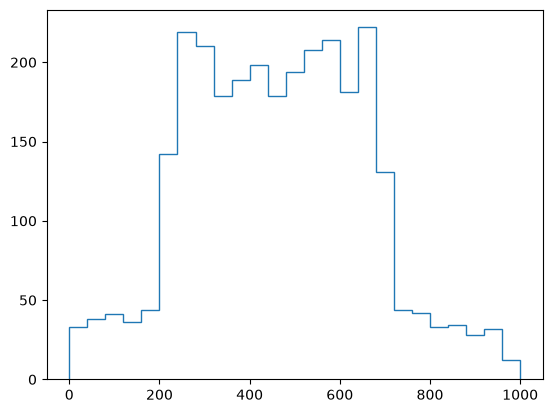

In [ ]:
sts = utils.load_spike_trains("data/Data1.nix")
counts, time_bins = utils.get_spike_time_histogram(sts, bin_size=40 * pq.ms);
plt.stairs(counts, time_bins);


**Exercise**: How does the `bin_size` parameter affect the quality of the time histogram?  Make histograms with a low `bin_size` and a high `bin_size` and compare the plots.  What compromise is made when selecting a bin size?
  - **Tip**: Use `density = True` when comparing histogram data, so to normalize the heights of the bins.

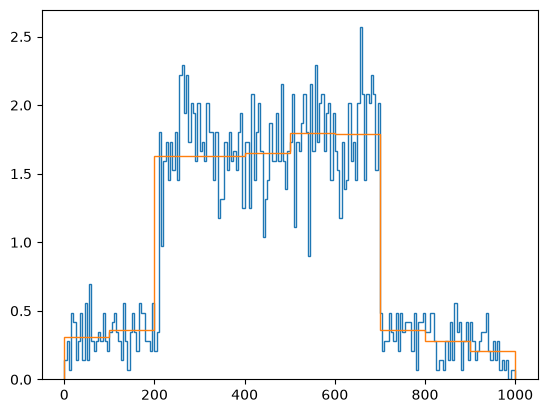

In [ ]:
sts = utils.load_spike_trains("data/Data1.nix")

counts, time_bins = utils.get_spike_time_histogram(sts, bin_size=5 * pq.ms, density=True);
plt.stairs(counts, time_bins);

counts, time_bins = utils.get_spike_time_histogram(sts, bin_size=100 * pq.ms, density=True);
plt.stairs(counts, time_bins);


**Example**: Does many spikes in a PSTH guarantee that the neuron was spiking rapidly (i.e., that it had a low **inter-spike interval (ISI)**)?  Let's check this by making a new rasterplot, this time coloring each raster with the spike's **intantaneous inter-spike interval**.  Do you see a difference in color distribution during the trial?

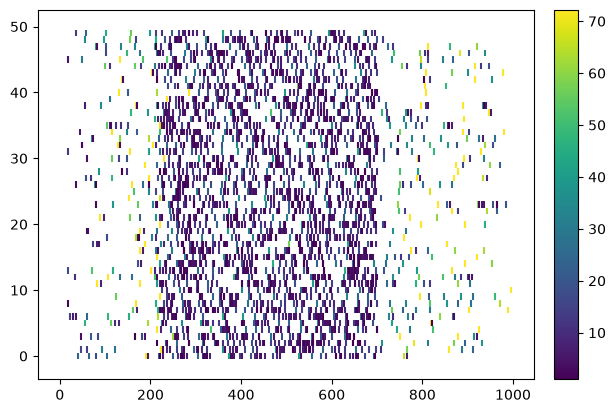

In [ ]:
sts = utils.load_spike_trains("data/Data1.nix")
spike_times = utils.get_spike_times(sts)
isis = utils.get_isis(sts)
utils.eventplot_colored(spike_times, isis);


**Exercise**: Inter-stimulus intervals tend to have a **exponential distribution**; for this reason, it is often difficult to get a lot of color detail from linear colorbars.  Using a different scale, like a Power scale, or cutting off extreme values, can increase the amount of detail visible in the plot.  

Let's try it out!  Adjust the `gamma`, `vmin_perc`, and `vmax_perc` parameters below to change the colorbar's range and improve the amount of information conveyed.  Can you make it clear where there are high, middle, and low ISIs?

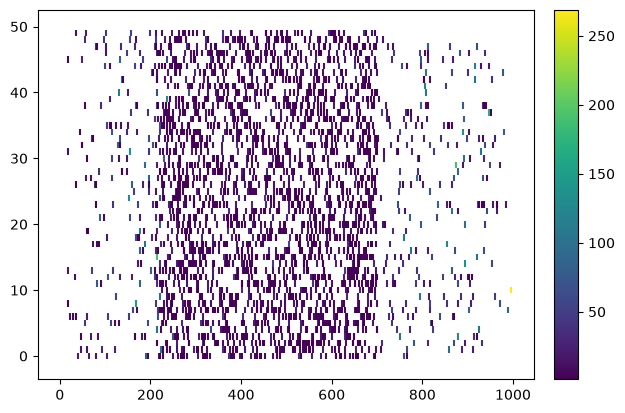

In [ ]:
sts = utils.load_spike_trains("data/Data1.nix")
spike_times = utils.get_spike_times(sts)
isis = utils.get_isis(sts)
utils.eventplot_colored(spike_times, isis, gamma=1., vmin_perc=.0001, vmax_perc=.9999);


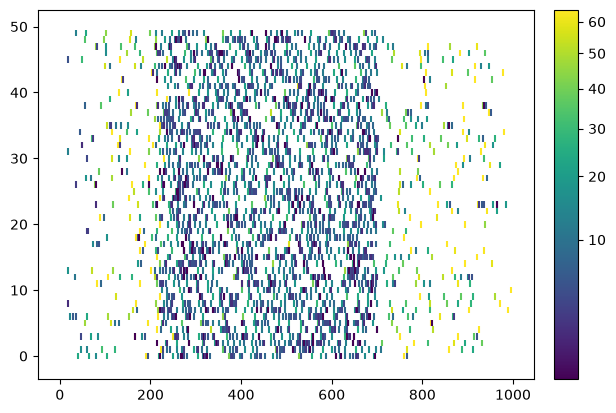

In [ ]:
sts = utils.load_spike_trains("data/Data1.nix")
spike_times = utils.get_spike_times(sts)
isis = utils.get_isis(sts)
utils.eventplot_colored(spike_times, isis, gamma=.5, vmin_perc=.03, vmax_perc=.97);


**Exercise**: You can also make a time histogram for the Inter-spike-Interval, showing how its binned average changes over time.  Let's try it!  Use the `utils.get_isi_time_histogram()` and the `plt.stairs()` functions to plot Data1's average ISIs over a `30 ms` bin size. 

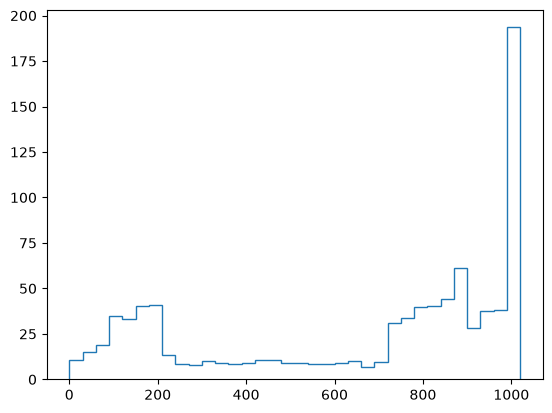

In [ ]:
sts = utils.load_spike_trains("data/Data1.nix")
isi_averages, time_bins = utils.get_isi_time_histogram(sts, bin_size=30 * pq.ms);
plt.stairs(isi_averages, time_bins);


## Making Comparisons with Matplotlib: Using Subplots and Axis Labeling for Richer Scientific Figures

Before we dive into statistical analyses of these spike trains, let's take a short detour and review our Matplotlib skills, as we'll be building ever-richer plots from here on out!  Here, we'll practice making subplots, labeling their axes, and labelling data objects inside a single Axis object.  This will also give us a chance to review the plots made in the previous section and explore how they relate to one another.

### Exercises

**Example**: Make a figure from `Data1` with multiple subplots, using the `plt.subplot()` function, and label the axes:
  - **upper-left corner**: a Spike Raster Plot
  - **upper-right corner**: an Instantaneous ISI Raster Plot (The colorful event plot)
  - **lower-left corner**: a Spike Time Histogram
  - **lower-right corner**: an ISI Time Histogram

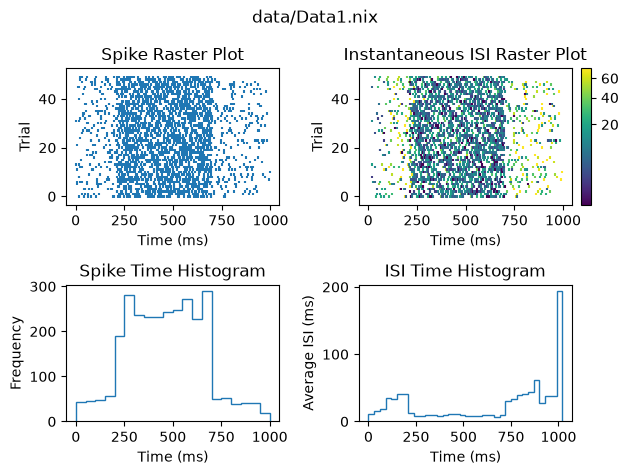

In [ ]:
fname = "data/Data1.nix"
sts = utils.load_spike_trains(fname)

plt.subplot(2, 2, 1)  # Figure 1 on a 2x2 grid
times = utils.get_spike_times(sts)
plt.eventplot(times);
plt.title('Spike Raster Plot')
plt.xlabel(f'Time (ms)')
plt.ylabel('Trial')

plt.subplot(2, 2, 2);  # Figure 2 on a 2x2 grid
isis = utils.get_isis(sts)
utils.eventplot_colored(times, isis, gamma=.4)
plt.title('Instantaneous ISI Raster Plot');
plt.xlabel(f'Time (ms)')
plt.ylabel('Trial')

plt.subplot(2, 2, 3);   # Figure 3 on a 2x2 grid
counts, time_bins = utils.get_spike_time_histogram(sts, bin_size=50 * pq.ms);
plt.stairs(counts, time_bins);
plt.title('Spike Time Histogram');
plt.xlabel(f'Time (ms)')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4);   # Figure 4 on a 2x2 grid
isi_averages, time_bins = utils.get_isi_time_histogram(sts, bin_size=30 * pq.ms);
plt.stairs(isi_averages, time_bins);
plt.title('ISI Time Histogram')
plt.xlabel(f'Time (ms)')
plt.ylabel('Average ISI (ms)')

plt.suptitle(fname)  # The "super" title for the whole figure.
plt.tight_layout();  # Makes final adjustments to spacing, to help prevent text from overlapping.

**Exercise**: How do the neurons from `Data20` and `Data21` compare to each other?  Make a figure with multiple subplots, using the plt.subplot() function, and label the axes:

left side: Data 20's Instantaneous ISI Raster Plot (The colorful event plot)
right side: Data 21's Instantaneous ISI Raster Plot (The colorful event plot)

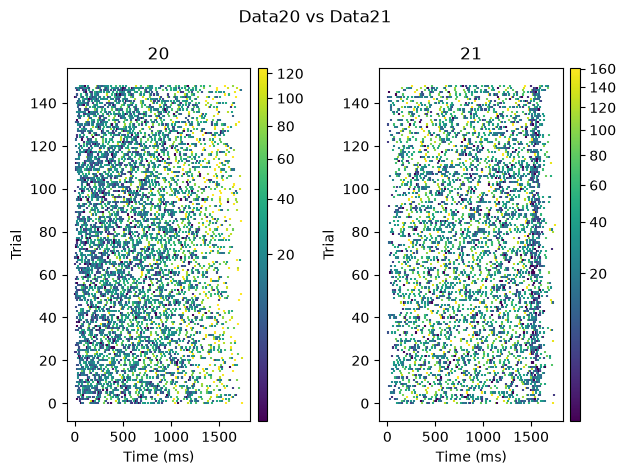

In [ ]:
plt.subplot(1, 2, 1)  # Figure 1 on a 2x2 grid
sts = utils.load_spike_trains("data/Data20.nix")
spike_times = utils.get_spike_times(sts)
isis = utils.get_isis(sts)
utils.eventplot_colored(spike_times, isis, gamma=.4)
plt.title('20');
plt.xlabel(f'Time (ms)')
plt.ylabel('Trial')

plt.subplot(1, 2, 2)  # Figure 1 on a 2x2 grid
sts = utils.load_spike_trains("data/Data21.nix")
spike_times = utils.get_spike_times(sts)
isis = utils.get_isis(sts)
utils.eventplot_colored(spike_times, isis, gamma=.4)
plt.title('21');
plt.xlabel(f'Time (ms)')
plt.ylabel('Trial')

plt.suptitle('Data20 vs Data21')  # The "super" title for the whole figure.
plt.tight_layout();  # Makes final adjustments to spacing, to help prevent text from overlapping.

**Exercise**: Do multiple cells have the spike timing pattern?  Let's compare their spike time histograms!  Make one plot with three different neuron's spike time histogram on it, in its own color.  To show which color line goes to which neuron, add a label when calling the plot function (i.e. `plt.eventplot(..., label='Data8')`), and create a legend once all the data has bee created with `plt.legend()`. *Tip:* Remember to use `density=True` when making the histogram.

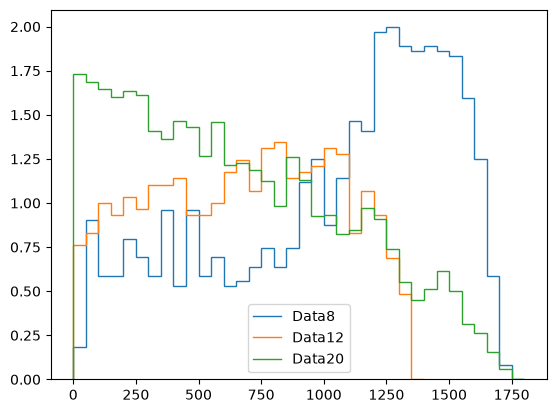

In [ ]:
sts = utils.load_spike_trains("data/Data8.nix")
plt.stairs(*utils.get_spike_time_histogram(sts, bin_size=50 * pq.ms, density=True), label='Data8');

sts = utils.load_spike_trains("data/Data12.nix")
plt.stairs(*utils.get_spike_time_histogram(sts, bin_size=50 * pq.ms, density=True), label='Data12');

sts = utils.load_spike_trains("data/Data20.nix")
plt.stairs(*utils.get_spike_time_histogram(sts, bin_size=50 * pq.ms, density=True), label='Data20');
plt.legend();

## Relating Neurons' Spike Times: Cross-Correlation Histograms

The cross-correlation histogram (CCH) estimates the tendency of neuron $y$ to fire at time lag $\tau$ after a spike in neuron $x$. A sharp peak at $\tau = 0$ ms indicates synchronous cofiring; a peak offset from zero indicates a directional interaction. Since individual trials are short, the CCH is computed per trial and averaged.  The goal is to learn how timing relationships can be measured, while also remembering that a visible peak is not yet proof of a meaningful interaction.

### Code Reference

| Code | Description |
| --- | --- |
| **`spike_trains = utils.load_spike_trains(data_id)`** | Load all trials for one neuron (returns a Python list, one spike train per trial) |
| **`b = conv.BinnedSpikeTrain(st, bin_size)`** | Bin spike train `st` |
| **`cch, lags = corr.cross_correlation_histogram(b1, b2, window=[-n, n])`** | Compute CCH between `b1` and `b2` for lags of ±`n` bins |
| **`cch_avg = sum(cchs) / len(cchs)`** | Average CCH over trials (works because Elephant returns `neo.AnalogSignal` objects that support arithmetic) |
| **`cch_avg.magnitude`** | CCH spike-count values as a plain numpy array |
| **`cch_avg.times.rescale("ms")`** | Lag axis of the CCH in milliseconds |
| **`utils.plot_cch(cch_avg)`** | Plot the CCH |

> **Working with spike trains and units**  
> Spike trains are `neo.SpikeTrain` objects — lists of spike times with attached physical units. Elephant functions accept them directly. When you need raw numbers (e.g. for plotting), use `st.rescale('ms').magnitude` to get a plain numpy array of times in milliseconds.  
> Parameters throughout this notebook carry physical units via the `quantities` library: `2 * pq.ms`, `100 * pq.ms`, `10 * pq.Hz`, etc. Just write them as shown — Elephant handles the rest.



### Exercises

The data consists of simultaneously recorded spike trains from pairs of neurons in the motor cortex of a macaque monkey performing a delayed reaching task. Each dataset contains spike trains across multiple trials. The following pairs are available for analysis: `[28, 29]`, `[23, 24]` (simulated data), `[12, 13]`, `[14, 15]`, `[20, 21]`, `[21, 22]` (experimental data).

In [ ]:
import elephant.conversion as conv
import elephant.spike_train_correlation as corr


**Example**: Reload `Data28, Data29`. Bin both spike trains from trial 0 with `bin_size=2*pq.ms` and compute the CCH with `maxlag=100*pq.ms`. Plot the result with `utils.plot_cch`.

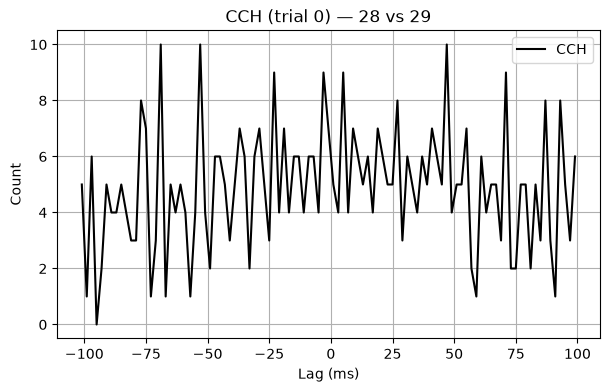

In [ ]:
spike_trains1 = utils.load_spike_trains('data/Data28.nix')
spike_trains2 = utils.load_spike_trains('data/Data29.nix')

bin_size = 2 * pq.ms
maxlag = 100 * pq.ms
num_lags = int((maxlag / bin_size).magnitude)

b1 = conv.BinnedSpikeTrain(spike_trains1[0], bin_size)
b2 = conv.BinnedSpikeTrain(spike_trains2[0], bin_size)
cch, lags = corr.cross_correlation_histogram(b1, b2, window=[-num_lags, num_lags])
utils.plot_cch(cch, title=f"CCH (trial 0) — 28 vs 29")

**Exercise**: Compute the CCH for the second trial (index `1`) with `bin_size=2*pq.ms` and compute the CCH with `maxlag=100*pq.ms`. Plot the result with `utils.plot_cch`.

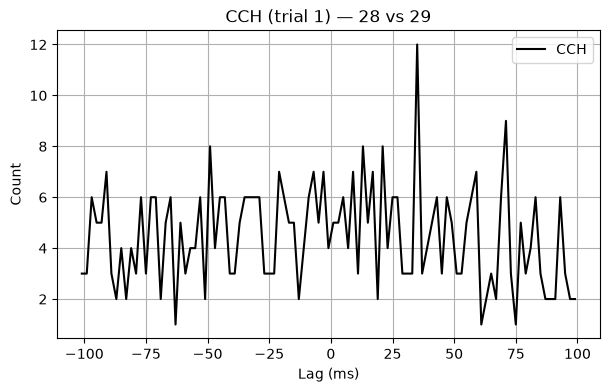

In [ ]:
spike_trains1 = utils.load_spike_trains('data/Data28.nix')
spike_trains2 = utils.load_spike_trains('data/Data29.nix')

bin_size = 2 * pq.ms
maxlag = 100 * pq.ms
num_lags = int((maxlag / bin_size).magnitude)

b1 = conv.BinnedSpikeTrain(spike_trains1[1], bin_size)
b2 = conv.BinnedSpikeTrain(spike_trains2[1], bin_size)
cch, lags = corr.cross_correlation_histogram(b1, b2, window=[-num_lags, num_lags])
utils.plot_cch(cch, title=f"CCH (trial 1) — 28 vs 29")

**Example**: Loop over all trials with `zip(spike_trains1, spike_trains2)`. For each pair, bin both spike trains with `bin_size` and compute the CCH using `window=[-num_lags, num_lags]`, and plot the CCH.  What feature do you observe at lag 0?

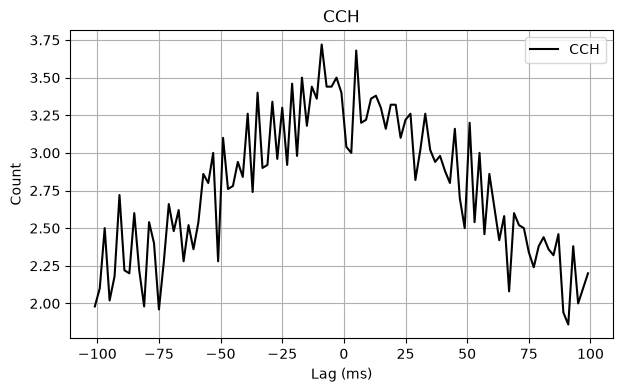

In [ ]:
spike_trains1 = utils.load_spike_trains('data/Data28.nix')
spike_trains2 = utils.load_spike_trains('data/Data29.nix')

bin_size = 2 * pq.ms
maxlag = 100 * pq.ms
num_lags = int((maxlag / bin_size).magnitude)

cchs = []
for st1, st2 in zip(spike_trains1, spike_trains2):
    b1 = conv.BinnedSpikeTrain(st1, bin_size)
    b2 = conv.BinnedSpikeTrain(st2, bin_size)
    cch, _ = corr.cross_correlation_histogram(b1, b2, window=[-num_lags, num_lags])
    cchs.append(cch)

cch_avg = sum(cchs) / len(cchs)
utils.plot_cch(cch_avg)

**Exercise**: Loop over all trials and compute the CCH for each pair, this time with a `maxlag` of `500*pq.ms`.  Does the CCH show any structure beyond ±100 ms?

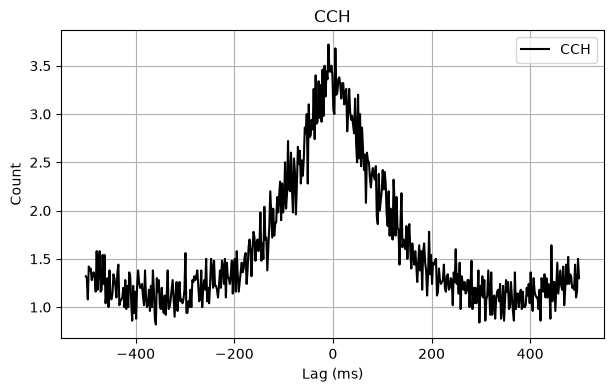

In [ ]:
spike_trains1 = utils.load_spike_trains('data/Data28.nix')
spike_trains2 = utils.load_spike_trains('data/Data29.nix')

bin_size = 2 * pq.ms
maxlag = 500 * pq.ms
num_lags = int((maxlag / bin_size).magnitude)

cchs = []
for st1, st2 in zip(spike_trains1, spike_trains2):
    b1 = conv.BinnedSpikeTrain(st1, bin_size)
    b2 = conv.BinnedSpikeTrain(st2, bin_size)
    cch, _ = corr.cross_correlation_histogram(b1, b2, window=[-num_lags, num_lags])
    cchs.append(cch)

cch_avg = sum(cchs) / len(cchs)
utils.plot_cch(cch_avg)

**Exercise**: Loop over all trials and compute the CCH for each pair, this time comparing neurons from `Data20.nix` an `Data21.nix`.  Is the structure different for this pair of neurons? Tip: A new `utils.compute_cch_avg()` function is available.

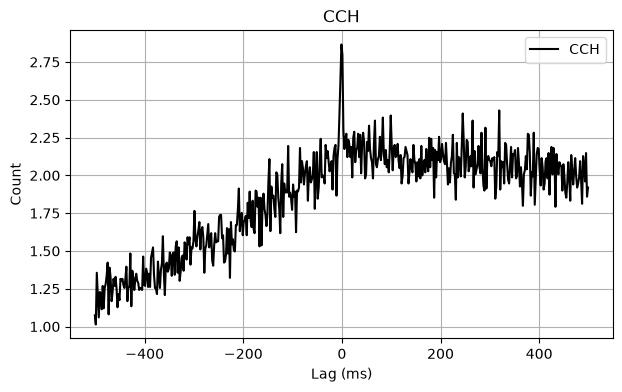

In [ ]:
spike_trains1 = utils.load_spike_trains('data/Data20.nix')
spike_trains2 = utils.load_spike_trains('data/Data21.nix')

bin_size = 2 * pq.ms
maxlag = 500 * pq.ms
num_lags = int((maxlag / bin_size).magnitude)

cch_avg = utils.compute_cch_avg(spike_trains1, spike_trains2, bin_size=bin_size, maxlag=maxlag)
utils.plot_cch(cch_avg)

**Exercise**: For `Data20, Data21`, compute and plot the trial averaged CCH with `bin_size=1*pq.ms` and then `bin_size=10*pq.ms`. How does the bin size affect the apparent peak width and the noise level?

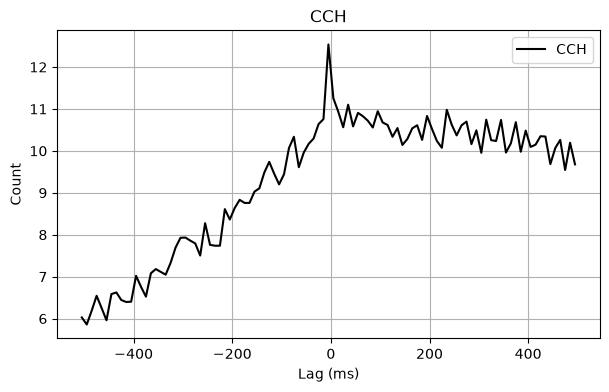

In [ ]:
spike_trains1 = utils.load_spike_trains('data/Data20.nix')
spike_trains2 = utils.load_spike_trains('data/Data21.nix')

bin_size = 10 * pq.ms
maxlag = 500 * pq.ms
num_lags = int((maxlag / bin_size).magnitude)

cch_avg = utils.compute_cch_avg(spike_trains1, spike_trains2, bin_size=bin_size, maxlag=maxlag)
utils.plot_cch(cch_avg)

**Exercise**: For `Data28, Data29`, check whether the trial averaged CCH is symmetric. Plot `cch_avg` and compare it to `cch_avg[::-1]`. Would you expect the CCH of two independent neurons to be perfectly symmetric?

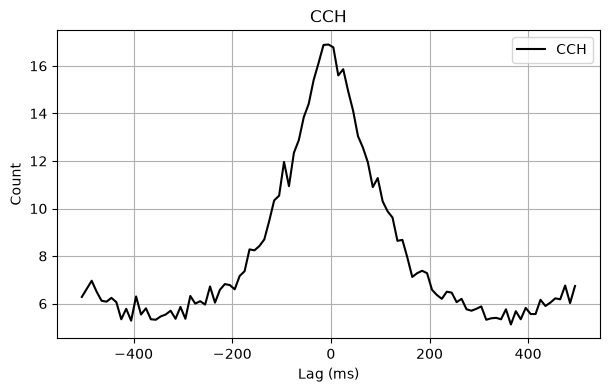

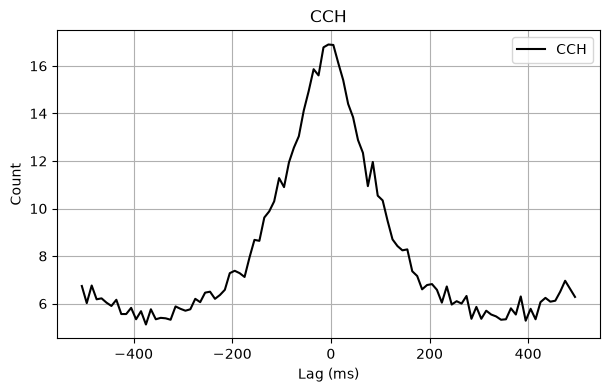

In [ ]:
spike_trains1 = utils.load_spike_trains('data/Data28.nix')
spike_trains2 = utils.load_spike_trains('data/Data29.nix')

bin_size = 10 * pq.ms
maxlag = 500 * pq.ms
num_lags = int((maxlag / bin_size).magnitude)

cch_avg = utils.compute_cch_avg(spike_trains1, spike_trains2, bin_size=bin_size, maxlag=maxlag)
utils.plot_cch(cch_avg)
utils.plot_cch(cch_avg[::-1])

**Exercise**: For `Data28, Data29`, compute `cch_avg` with `bin_size=2*pq.ms`. Find the lag at which the CCH is maximum using `utils.find_peak_lag(cch_avg)`. Does the maximum occur at lag 0?

In [ ]:
spike_trains1 = utils.load_spike_trains('data/Data28.nix')
spike_trains2 = utils.load_spike_trains('data/Data29.nix')

bin_size = 2 * pq.ms
maxlag = 500 * pq.ms
num_lags = int((maxlag / bin_size).magnitude)

cch_avg = utils.compute_cch_avg(spike_trains1, spike_trains2, bin_size=bin_size, maxlag=maxlag)

utils.find_peak_lag(cch_avg)

array(-9.) * ms

## Comparing Cross Correlation Histograms to a Null Distribution by Generating Surrogate Data

### Spike Dithering Surrogates

A peak in the CCH may arise by chance from the neurons' individual firing rates alone. Surrogate data provides a null distribution: randomised spike trains that preserve firing statistics but destroy fine temporal correlations. If the original CCH exceeds the surrogate threshold, the correlation is significant.

Spike dithering tests whether precise spike timing matters. In this method, each spike is moved by a small random amount, drawn uniformly from `[-dither, +dither]`. This destroys synchrony while approximately preserving the instantaneous firing rate at each point in time.

| Code | Description |
| --- | --- |
| `surr.surrogates(st, n_surrogates=100, method="dither_spike_train", dt=8*pq.ms)` | Generate 100 dithered surrogates of spike train `st` |
| `[surr.surrogates(st, n_surrogates=n_surr, method="dither_spike_train", dt=dither) for st in spike_trains1]` | Generate surrogates for all trials of neuron 1 |
| `utils.compute_surrogate_cchs(surr1, surr2, n_surr, bin_size, maxlag)` | Compute surrogate CCHs; returns an array of shape `(n_surr, len_cch)` |
| `np.quantile(cchs_surr, 0.95, axis=0)` | 95th percentile significance threshold across surrogates |

---

#### **Exercises**

**Explore**: Explore the parameters in the code below:
  - Is the CCH peak at lag 0 above the 95th percentile threshold?
  - Increase `n_surr` from 20 to 100 and rerun the dithering surrogate analysis for `Data28, Data29`. Does the 95th percentile threshold change? Is the original CCH peak at lag 0 still above the threshold?
  - How does the `dither` width affect the significance threshold and the mean surrogate CCH?

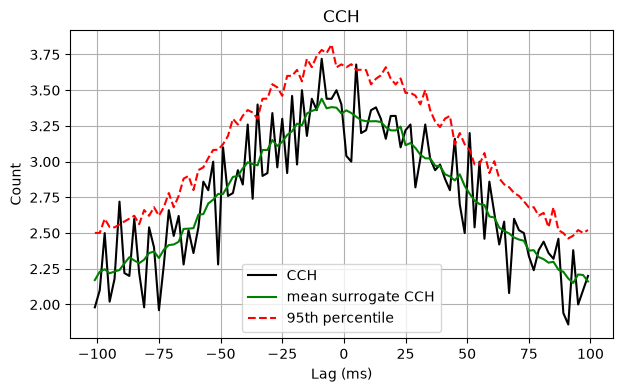

In [ ]:
spike_trains1 = utils.load_spike_trains('data/Data28.nix')
spike_trains2 = utils.load_spike_trains('data/Data29.nix')

bin_size = 2 * pq.ms
maxlag = 100 * pq.ms

cch_avg = utils.compute_cch_avg(spike_trains1, spike_trains2, bin_size = bin_size, maxlag=100 * pq.ms)

n_surr = 100
dither = 8 * pq.ms
surr1_dith = [surr.surrogates(st, n_surrogates=n_surr, method="dither_spike_train", dt=dither)
              for st in spike_trains1]
surr2_dith = [surr.surrogates(st, n_surrogates=n_surr, method="dither_spike_train", dt=dither)
              for st in spike_trains2]
cchs_surr = utils.compute_surrogate_cchs(surr1_dith, surr2_dith, n_surr, bin_size, maxlag)

cch_mean = np.mean(cchs_surr, axis=0)
cch_threshold = np.quantile(cchs_surr, 0.95, axis=0)

utils.plot_cch(cch_avg, cch_mean, cch_threshold)

### Trial Shuffling Surrogates

Trial shuffling pairs the spike train of neuron 1 from trial $i$ with the spike train of neuron 2 from a randomly chosen trial $j$. This destroys within trial covariation between neurons while preserving the PSTH of each neuron exactly. It is particularly suited for data with non stationary firing rates, since it does not alter the rate profile.

| Code | Description |
| --- | --- |
| `np.random.permutation(n)` | Random permutation of the integers `0, 1, ..., n-1` |
| `surr1_shf[i].append(spike_trains1[random_idx[i]])` | Assign the shuffled trial to surrogate index `i` |
| `utils.compute_surrogate_cchs(surr1_shf, surr2_shf, n_surr, bin_size, maxlag)` | Compute surrogate CCHs from the shuffled lists |

---

#### **Exercises**

**Example**: For `Data28, Data29`, generate 100 trial shuffled surrogates.

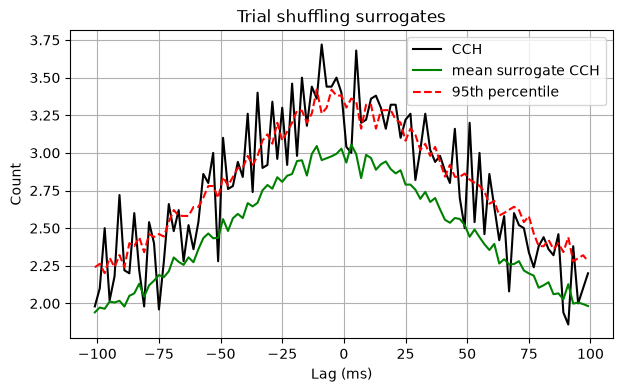

In [ ]:
spike_trains1 = utils.load_spike_trains('data/Data28.nix')
spike_trains2 = utils.load_spike_trains('data/Data29.nix')

num_trials = len(spike_trains1)
surr1_shf = [[] for _ in range(num_trials)]
surr2_shf = [[] for _ in range(num_trials)]
for _ in range(n_surr):
    random_idx = np.random.permutation(num_trials)
    for i in range(num_trials):
        surr1_shf[i].append(spike_trains1[random_idx[i]])
        surr2_shf[i].append(spike_trains2[i])


cchs_surr_shf = utils.compute_surrogate_cchs(surr1_shf, surr2_shf, n_surr, bin_size, maxlag)
cch_mean_shf = np.mean(cchs_surr_shf, axis=0)
cch_threshold_shf = np.quantile(cchs_surr_shf, 0.95, axis=0)
utils.plot_cch(cch_avg, cch_mean_shf, cch_threshold_shf, title="Trial shuffling surrogates")

**Exercise**: Generate `n_surr=100` trial shuffling surrogates for the same data (`Data20, Data21`). Compute and plot the threshold with `utils.plot_cch`. For which surrogate method does the CCH at lag 0 exceed the threshold?

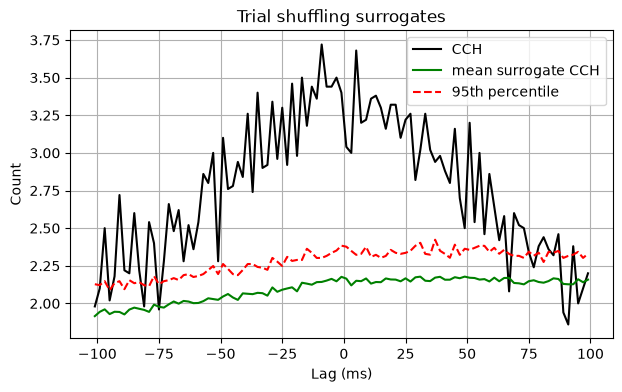

In [ ]:
spike_trains1 = utils.load_spike_trains('data/Data20.nix')
spike_trains2 = utils.load_spike_trains('data/Data21.nix')

num_trials = len(spike_trains1)
surr1_shf = [[] for _ in range(num_trials)]
surr2_shf = [[] for _ in range(num_trials)]
for _ in range(n_surr):
    random_idx = np.random.permutation(num_trials)
    for i in range(num_trials):
        surr1_shf[i].append(spike_trains1[random_idx[i]])
        surr2_shf[i].append(spike_trains2[i])


cchs_surr_shf = utils.compute_surrogate_cchs(surr1_shf, surr2_shf, n_surr, bin_size, maxlag)
cch_mean_shf = np.mean(cchs_surr_shf, axis=0)
cch_threshold_shf = np.quantile(cchs_surr_shf, 0.95, axis=0)
utils.plot_cch(cch_avg, cch_mean_shf, cch_threshold_shf, title="Trial shuffling surrogates")

**Explore**: Examine the figure below.  For `Data28, Data29`, plotted is the dithering threshold and the shuffling threshold in the same figure. Which method produces a flatter (more uniform) threshold across lags? What does that flatness tell you about the assumptions of trial shuffling?

In [ ]:
dither = 8 * pq.ms
surr1_dith = [surr.surrogates(st, n_surrogates=n_surr, method="dither_spike_train", dt=dither)
              for st in spike_trains1]
surr2_dith = [surr.surrogates(st, n_surrogates=n_surr, method="dither_spike_train", dt=dither)
              for st in spike_trains2]
cchs_surr_dith = utils.compute_surrogate_cchs(surr1_dith, surr2_dith, n_surr, bin_size, maxlag)
cch_threshold_dith = np.quantile(cchs_surr_dith, 0.95, axis=0)

lags = cch_avg.times.rescale("ms").magnitude
plt.plot(lags, cch_threshold_dith, label="dithering threshold")
plt.plot(lags, cch_threshold_shf, label="shuffling threshold")
plt.xlabel("Lag (ms)")
plt.ylabel("Count")
plt.legend()

### Spike Time Randomisation Surrogates

Spike dithering is not the only approach to generating surrogate data. *Spike time randomisation* places each spike uniformly at random within the recording window, preserving only the total spike count per trial. This destroys both precise temporal correlations **and** the firing rate profile over time. The resulting surrogate CCH therefore represents only what is expected from the mean firing rates, making it a stronger null model than dithering.

| Code | Description |
| --- | --- |
| `surr.surrogates(st, n_surrogates=n_surr, method="randomise_spikes")` | Place each spike uniformly at random within the trial |

---

#### **Exercises**

**Explore**: For `Data28, Data29`, generate 100 randomise_spikes surrogates and compute the trial-averaged CCH and significance threshold.

In [ ]:
spike_trains1 = utils.load_spike_trains('data/Data28.nix')
spike_trains2 = utils.load_spike_trains('data/Data29.nix')
bin_size = 2 * pq.ms
maxlag = 100 * pq.ms
num_lags = int((maxlag / bin_size).magnitude)
cchs = []
for st1, st2 in zip(spike_trains1, spike_trains2):
    b1 = conv.BinnedSpikeTrain(st1, bin_size)
    b2 = conv.BinnedSpikeTrain(st2, bin_size)
    cch, _ = corr.cross_correlation_histogram(b1, b2, window=[-num_lags, num_lags])
    cchs.append(cch)
cch_avg = sum(cchs) / len(cchs)
n_surr = 100
surr1_rnd = [surr.surrogates(st, n_surrogates=n_surr, method="randomise_spikes")
             for st in spike_trains1]
surr2_rnd = [surr.surrogates(st, n_surrogates=n_surr, method="randomise_spikes")
             for st in spike_trains2]
cchs_surr_rnd = utils.compute_surrogate_cchs(surr1_rnd, surr2_rnd, n_surr, bin_size, maxlag)
cch_mean_rnd = np.mean(cchs_surr_rnd, axis=0)
cch_threshold_rnd = np.quantile(cchs_surr_rnd, 0.95, axis=0)
utils.plot_cch(cch_avg, cch_mean_rnd, cch_threshold_rnd,
               title=f"Data28 vs Data29 — randomise_spikes")

**Explore**: Plot the dithering threshold (`dither=8*pq.ms`, `n_surr=100`) and the randomise_spikes threshold in the same figure for `Data28, Data29`. Which threshold is higher at lag 0? What does that tell you about what each surrogate method preserves from the original spike train?

In [ ]:
dither = 8 * pq.ms
surr1_dith = [surr.surrogates(st, n_surrogates=n_surr, method="dither_spike_train", dt=dither)
              for st in spike_trains1]
surr2_dith = [surr.surrogates(st, n_surrogates=n_surr, method="dither_spike_train", dt=dither)
              for st in spike_trains2]
cchs_surr_dith = utils.compute_surrogate_cchs(surr1_dith, surr2_dith, n_surr, bin_size, maxlag)
cch_threshold_dith = np.quantile(cchs_surr_dith, 0.95, axis=0)
lags = cch_avg.times.rescale("ms").magnitude
plt.plot(lags, cch_threshold_dith, label="dithering")
plt.plot(lags, cch_threshold_rnd, label="randomise_spikes")
plt.xlabel("Lag (ms)")
plt.ylabel("Count")
plt.title(f"Threshold comparison — Data28 vs Data29")
plt.legend()

**Explore**: Repeat the `randomise_spikes` surrogate analysis for `Data20, Data21`. Does the CCH at lag 0 exceed the threshold? Compare the result to what you found using dithering for the same data. Which method is more appropriate for data with non-stationary firing rates, and why?

In [ ]:
data_id1, data_id2 = 20, 21
spike_trains1 = utils.load_spike_trains(data_id1)
spike_trains2 = utils.load_spike_trains(data_id2)
cchs_2021 = []
for st1, st2 in zip(spike_trains1, spike_trains2):
    b1 = conv.BinnedSpikeTrain(st1, bin_size)
    b2 = conv.BinnedSpikeTrain(st2, bin_size)
    cch, _ = corr.cross_correlation_histogram(b1, b2, window=[-num_lags, num_lags])
    cchs_2021.append(cch)
cch_avg_2021 = sum(cchs_2021) / len(cchs_2021)
surr1_rnd = [surr.surrogates(st, n_surrogates=n_surr, method="randomise_spikes")
             for st in spike_trains1]
surr2_rnd = [surr.surrogates(st, n_surrogates=n_surr, method="randomise_spikes")
             for st in spike_trains2]
cchs_surr_rnd = utils.compute_surrogate_cchs(surr1_rnd, surr2_rnd, n_surr, bin_size, maxlag)
cch_mean_rnd = np.mean(cchs_surr_rnd, axis=0)
cch_threshold_rnd = np.quantile(cchs_surr_rnd, 0.95, axis=0)
utils.plot_cch(cch_avg_2021, cch_mean_rnd, cch_threshold_rnd,
               title=f"Data{data_id1} vs Data{data_id2} — randomise_spikes")